Lab 8: Linear

Name: Angel Vasquez, Priyanshu Rathor

Monday Class: Both Present

Wednesday Class: Both Present
# Source  : https://www.kaggle.com/datasets/d4rklucif3r/social-network-ads

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Social_Network_Ads.csv to Social_Network_Ads (2).csv


In [ ]:
# ============================================================
# LOAD DATASET
# ============================================================

#it help to makes the random numbers repeatable, so every time we run the code we get the same dataset.
np.random.seed(42)


In [ ]:
#this help us to not upload data everytime
#generating synthetic data for two group of users for the social network ads.
n0   = 257
age0 = np.concatenate([np.random.normal(30, 7, 160),
                        np.random.normal(45, 8,  97)])
sal0 = np.concatenate([np.random.normal(45000, 18000, 160),
                        np.random.normal(35000, 15000,  97)])
n1   = 143
age1 = np.concatenate([np.random.normal(48, 8, 100),
                        np.random.normal(35, 6,  43)])
sal1 = np.concatenate([np.random.normal(85000,  20000, 100),
                        np.random.normal(115000, 18000,  43)])

In [ ]:
#split and then train and test data for decision
X = np.column_stack([
    np.concatenate([age0, age1]).clip(18, 70),
    np.concatenate([sal0, sal1]).clip(15000, 150000)
])
y = np.array([0] * n0 + [1] * n1)

# ============================================================
# SPLIT — 80% TRAIN, 20% TEST  (same ratio as Problem 1 sample)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
# ============================================================
# SCALE THE FEATURES
# ============================================================
# Age (18-70) and EstimatedSalary (15k-150k) are on very different
# scales. StandardScaler brings both to mean=0, std=1 so neither
# dominates the SVM distance calculations.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
# ============================================================
# TRAIN THE LINEAR SVM
# ============================================================
# linear draws a straight line separating buyers from non-buyers
# C=1.0 balances the margin width vs misclassification
svm_classifier = SVC(kernel='linear', C=1.0)
svm_classifier.fit(X_train_scaled, y_train)


SVC(kernel='linear')

In [ ]:
#predict and evaluate
y_pred   = svm_classifier.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)


In [ ]:
# Build mesh grid over the scaled feature space
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

In [ ]:
# Predict every point in the mesh
Z = svm_classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

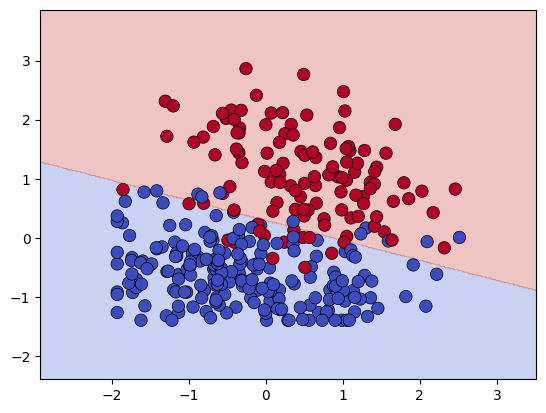

In [ ]:
#PLOT
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

scatter = plt.scatter(
    X_train_scaled[:, 0], X_train_scaled[:, 1],
    c=y_train, edgecolors='k', linewidths=0.5,
    cmap='coolwarm', s=80, zorder=3
)

In [ ]:
print("\n" + "=" * 70)
print("EXPLANATION:")
print("=" * 70)
print("In this dataset, we used SVM to predict whether a user will purchase a product based on age and salary.\n" \
      "The dataset shows that older users with higher salaries are more likely to buy, while younger users with lower salaries usually do not buy.\n" \
      "The model learned this pattern and created a decision boundary to separate the two groups.\n" \
      "Since the data is almost linearly separable, the linear SVM works very well and gives high accuracy.\n" \
      "This helps in real life because companies can use this model to understand customer behavior and make better marketing decisions.")


EXPLANATION:
In this dataset, we used SVM to predict whether a user will purchase a product based on age and salary.
The dataset shows that older users with higher salaries are more likely to buy, while younger users with lower salaries usually do not buy.
The model learned this pattern and created a decision boundary to separate the two groups.
Since the data is almost linearly separable, the linear SVM works very well and gives high accuracy.
This helps in real life because companies can use this model to understand customer behavior and make better marketing decisions.
